In [1]:
import torch
import numpy as np
import os,sys

sys.path.append('../..')

# parametres 
data_set_name = 'gowalla'
# device='cuda:0'
device = 'cpu'

topk = 20
optimizer = lambda params: torch.optim.Adam(params, lr=1e-3, amsgrad=True)
have_processed_data = True

emb_dim = 96
sum_pooling = False
sample_negative_num = 60
feature_groups = [20, 20, 10, 10, 2, 2, 2, 1, 1, 1]
train_sample_seg_cnt = 10 #the training data is located in the train_sample_seg_cnt datafiles

parall = 10
seq_len = 70 # se_len-1 is the number of behaviours in all the windows
min_seq_len = 15

test_user_num = 6000 # the number of user in test file

raw_data_file               = '../../data/{}/{}.txt'.format(data_set_name, data_set_name)

train_instances_file        = '../../data/{}/train_instances'.format(data_set_name)
test_instances_file         = '../../data/{}/test_instances'.format(data_set_name)
validation_instances_file   = '../../data/{}/validation_instances'.format(data_set_name)

item_num_node_num_file      = '../../data/{}/item_node_num.txt'.format(data_set_name)
result_prefix               = '../../data/result/DIN/'

training_batch_size = 256
test_batch_size = 16
batch_number = 100

if device != 'cpu':
    torch.cuda.set_device(device)
    device = 'cuda'

%load_ext autoreload
%autoreload 2

In [2]:
import lib
from lib import generate_train_and_test_data
import gc
import numpy as np

if not have_processed_data: 
    behavior_dict, train_sample, test_sample, user_num, item_num, item_vec =  generate_train_and_test_data._read(
        raw_data_file, 
        'train.dat', 
        'test.dat',
        test_user_num
    )

    # write the training instance into different train_sample_seg_cnt files， avoid that a file is too large
    # stat record the click frequency of each item
    # seq_len=20 min that 19 behaviors and one label
    stat = generate_train_and_test_data._gen_train_sample(
        train_sample, 
        train_instances_file,
        test_sample=test_sample,
        train_sample_seg_cnt=train_sample_seg_cnt,
        parall=parall, 
        seq_len=seq_len, 
        min_seq_len=min_seq_len
    )
    generate_train_and_test_data._gen_test_sample(
        test_sample, 
        test_instances_file, 
        seq_len=seq_len,
        min_seq_len=min_seq_len
    )
    del behavior_dict
    del train_sample
    del test_sample
    del stat
    np.savetxt(
        item_num_node_num_file,np.array([user_num,item_num]),
        fmt='%d',
        delimiter=','
    )
else:
    [user_num, item_num] = np.loadtxt(
        item_num_node_num_file,
        dtype=np.int32,
        delimiter=','
    )
print('user num is {}, item is {}'.format(user_num, item_num))

user num is 13583, item is 71436


In [3]:
from lib import DINTrain

train_model=DINTrain(
    item_num=item_num,
    sample_negative_num=sample_negative_num,
    emb_dim=emb_dim,
    device=device,
    sum_pooling=sum_pooling,
    feature_groups=feature_groups,
    optimizer=optimizer
)
print(train_model.DINModel)

DeepInterestNetwork(
  (item_embedding): EmbeddingLayer(
    (embed): Embedding(71437, 96, padding_idx=71436)
  )
  (attention_unit): LocalActivationUnit(
    (fc1): FullyConnectedLayer(
      (fc): Sequential(
        (0): Linear(in_features=384, out_features=64, bias=True)
        (1): Dice(
          (bn): BatchNorm1d(64, eps=1e-09, momentum=0.1, affine=True, track_running_stats=True)
          (sigmoid): Sigmoid()
        )
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=64, out_features=16, bias=True)
      )
    )
    (fc2): FullyConnectedLayer(
      (fc): Sequential(
        (0): Linear(in_features=16, out_features=1, bias=True)
      )
    )
  )
  (fc_layer): FullyConnectedLayer(
    (fc): Sequential(
      (0): Linear(in_features=1056, out_features=200, bias=True)
      (1): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): Dice(
        (bn): BatchNorm1d(200, eps=1e-09, momentum=0.1, affine=True, track_runn

In [4]:
from pandas import DataFrame
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

moving_average = lambda x, **kw: DataFrame({'x' : np.asarray(x)}).x.ewm(**kw).mean().values

# 训练曲线缓存
loss_history = []

# 评估指标函数，比如 precision、recall、f_measure、novelty、hit_ratio、NDCG、MAP
dev_precision_history = []
dev_recall_history = [] 
dev_f_measure_history = []
dev_novelty_history = []

total_precision_history = []
total_recall_history = []
total_f_measure_history = []
total_novelty_history = []

In [5]:
# 1. Precision（精确率）
# 推荐的结果里，有多少是用户真正喜欢的→ 越高说明推荐越准
# 2. Recall（召回率）
# 用户喜欢的东西，有多少被你推荐出来了→ 越高说明覆盖越全
# 3. F-measure（F1 分数）
# Precision + Recall 的综合分数→ 越高说明整体效果越好
# 4. Novelty（新颖度）
# 推荐结果的多样性 / 新奇度→ 越高说明推荐不重复、不单调

def presision(result_list, gt_list, top_k):
    """计算precision指标
    :param result_list: list of list, 每个list是一个用户的推荐结果
    :param gt_list: list of list, 每个list是一个用户的真实点击结果
    :param top_k: int, 推荐结果的长度
    :return: float, precision指标的值
    """
    count = 0.0
    for r, g in zip(result_list, gt_list):
        count += len(set(r).intersection(set(g)))
    return count / (top_k * len(result_list))

def recall(result_list, gt_list):
    """计算recall指标
    :param result_list: list of list, 每个list是一个用户的推荐结果
    :param gt_list: list of list, 每个list是一个用户的真实点击结果
    :return: float, recall指标的值
    """
    t = 0.0
    for r, g in zip(result_list, gt_list):
        t += 1.0 * len(set(r).intersection(set(g))) / len(g)
    return t / len(result_list)

def f_measure(result_list, gt_list, top_k, eps=1.0e-9):
    """计算f_measure指标
    :param result_list: list of list, 每个list是一个用户的推荐结果
    :param gt_list: list of list, 每个list是一个用户的真实点击结果
    :param top_k: int, 推荐结果的长度
    :param eps: float, 防止除零的极小值
    :return: float, f_measure指标的值
    """
    f = 0.0
    for r, g in zip(result_list, gt_list):
        recc = 1.0 * len(set(r).intersection(set(g))) / len(g)
        pres = 1.0 * len(set(r).intersection(set(g))) / top_k
        if recc + pres < eps:
            continue
        f += (2 * recc * pres) / (recc + pres)
    return f / len(result_list)

def novelty(result_list, s_u, top_k):
    """计算novelty指标
    :param result_list: list of list, 每个list是一个用户的推荐结果
    :param s_u: list of list, 每个list是一个用户的历史点击结果
    :param top_k: int, 推荐结果的长度
    :return: float, novelty指标的值
    """
    count = 0.0
    for r, g in zip(result_list, s_u):
        count += len(set(r) - set(g))
    return count / (top_k * len(result_list))

def hit_ratio(result_list, gt_list):
    """计算hit_ratio指标
    :param result_list: list of list, 每个list是一个用户的推荐结果
    :param gt_list: list of list, 每个list是一个用户的真实点击结果
    :return: float, hit_ratio指标的值
    """
    intersect_set = [len(set(r) & set(g)) for r, g in zip(result_list, gt_list)]
    return 1.0 * sum(intersect_set) / sum([len(gts) for gts in gt_list])

def NDCG(result_list, gt_list):
    """计算NDCG指标
    :param result_list: list of list, 每个list是一个用户的推荐结果
    :param gt_list: list of list, 每个list是一个用户的真实点击结果
    :return: float, NDCG指标的值
    """
    t = 0.0
    for re, gt in zip(result_list, gt_list):
        setgt = set(gt)
        indicator = np.asfarray([1 if r in setgt else 0 for r in re])
        sorted_indicator = np.ones(min(len(setgt), len(re)))
        if 1 in indicator:
            t+=np.sum(indicator / np.log2(1.0*np.arange(2,len(indicator)+ 2)))/\
               np.sum(sorted_indicator/np.log2(1.0*np.arange(2,len(sorted_indicator)+ 2)))
    return t/len(gt_list)

def MAP(result_list, gt_list, topk):
    """计算MAP指标
    :param result_list: list of list, 每个list是一个用户的推荐结果
    :param gt_list: list of list, 每个list是一个用户的真实点击结果
    :param topk: int, 推荐结果的长度
    :return: float, MAP指标的值
    """
    t = 0.0
    for re, gt in zip(result_list, gt_list):
        setgt = set(gt)
        indicator = np.asfarray([1 if r in setgt else 0 for r in re])
        t += np.mean([indicator[:i].sum(-1) / i for i in range(1, topk + 1)], axis=-1)
    return t/len(gt_list)

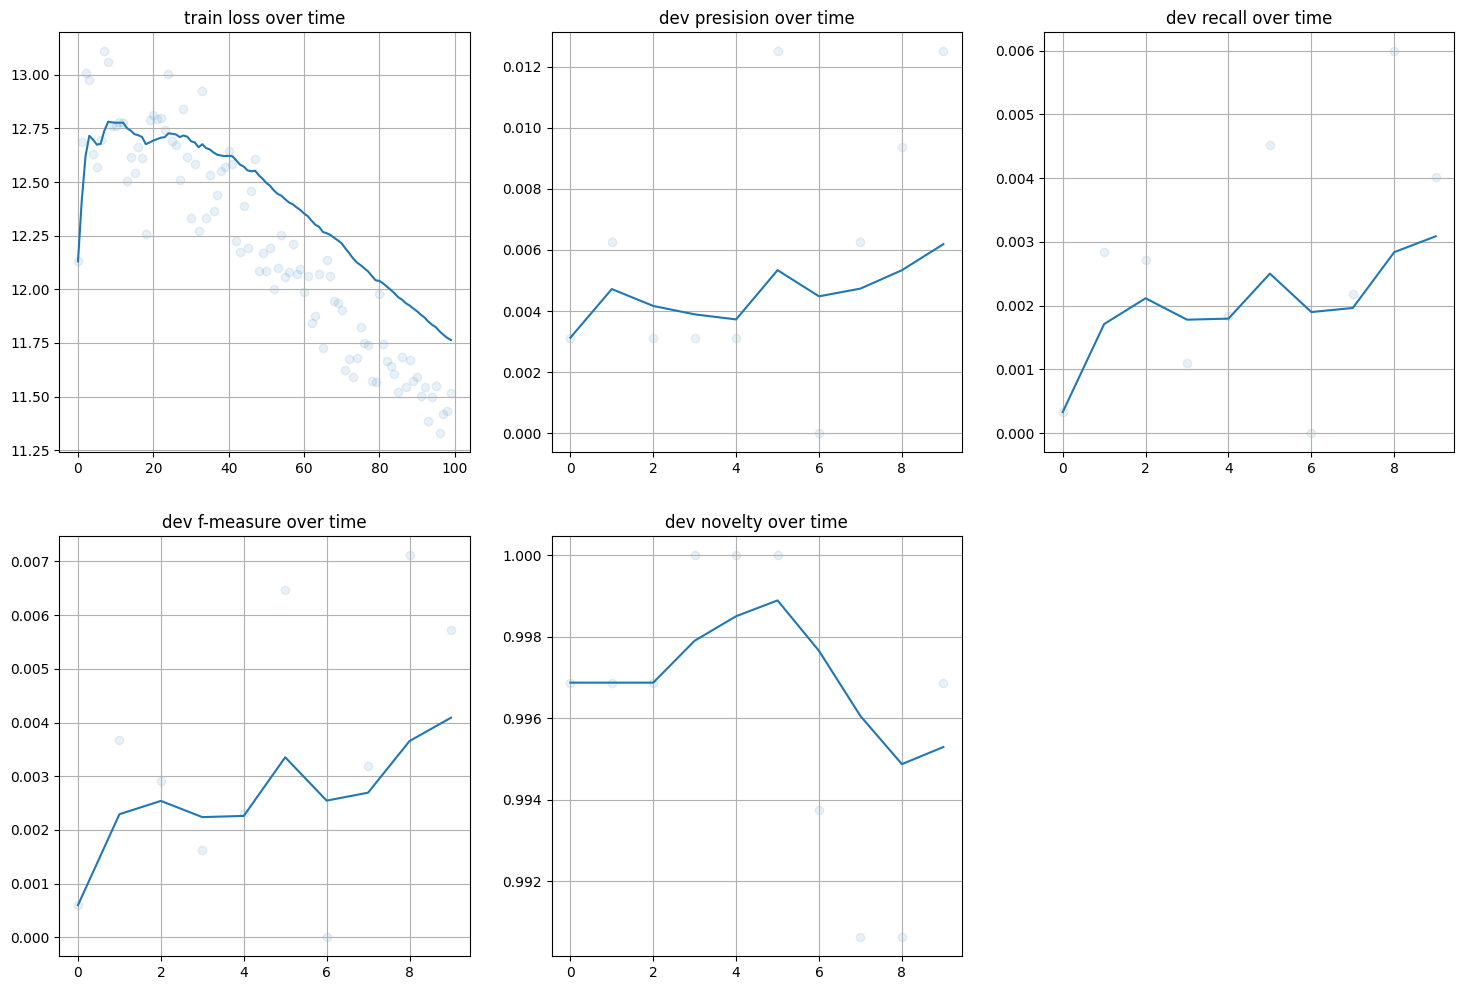

step=100, mean_loss=12.189, time=1.000
____________________________________________________________________________________________________
train_model.batch_num: 100


In [6]:
# train_model.DINModel.train()

from lib.generate_training_batches import Train_instance

train_instances = Train_instance(parall=parall)

### train
# 方式1: 每轮训练都重新读所有文件！
# training_batch_generator = train_instances.training_batches(
#     train_instances_file,
#     train_sample_seg_cnt,
#     item_num,
#     batchsize=training_batch_size
# )

# 方式2: 只读一次文件 → 全程内存跑 → 无限循环生成batch → 训练最快最稳！
training_data, training_labels = train_instances.get_training_data(
    train_instances_file,
    train_sample_seg_cnt,
    item_num
)
train_batch_generator = train_instances.generate_training_records(
    training_data, 
    training_labels, 
    batch_size=training_batch_size
)

### validation
validation_batch_generator = train_instances.validation_batches(
    validation_instances_file,
    item_num,
    batchsize=test_batch_size
)

### test
test_batch_generator = train_instances.test_batches(
    test_instances_file,
    item_num,
    batchsize=test_batch_size
)

for (batch_x, batch_y) in train_batch_generator:
    # print(batch_x, batch_y)
    print(f"train_model.batch_num: {train_model.batch_num}")
    loss = train_model.update_DIN(batch_x, batch_y)
    loss_history.append(loss.item())
    
    # 每5000step, 拿一批validation user, 对所有item暴力打分, 再算一次排序指标
    if train_model.batch_num % 5000 == 0:
        # ###start to validation
        # Note. 全量item分批计算, 防止爆显存
        train_model.DINModel.eval()
        test_batch, test_index = validation_batch_generator.__next__()
        # (batch_size, item_num). the preference matrix, which is used to store the preference score of each user for each item
        preference_matrix = torch.full((len(test_batch), item_num), -1.0e9, dtype=torch.float32)
        all_items = torch.arange(item_num, device=device).view(-1, 1)
        item_bs = 2000
        for i, user in enumerate(test_batch):
            start_id = 0
            while start_id < item_num:
                # (item_bs, 1)
                part_labels = all_items[start_id : start_id + item_bs, :]
                # (1, f_num) -> (item_bs, f_num)
                user_history = user.to(device).expand(len(part_labels), test_batch.shape[1])

                # print(len(part_labels), len(user_history))
                with torch.no_grad():
                    preference_matrix[i, start_id : start_id + item_bs] = train_model.calculate_preference(
                        user_history,
                        part_labels
                    ).view(1, -1).cpu()
                start_id = start_id + item_bs
        result_history = preference_matrix.argsort(dim=-1)[:, -topk:].numpy()
        gt_history = [train_instances.validation_labels[i.item()] for i in test_index]
        total_precision_history.append(presision(result_history, gt_history, topk))         # precision
        total_recall_history.append(recall(result_history, gt_history))                     # recall
        total_f_measure_history.append(f_measure(result_history, gt_history, topk))         # f_measure
        total_novelty_history.append(novelty(result_history, test_batch.tolist(), topk))    # novelty
        train_model.DINModel.train()
            
    # 每 10 step, 只是画图和打印训练情况
    if train_model.batch_num % 10 == 0:
        ### start to validation
        train_model.DINModel.eval()
        test_batch, test_index = validation_batch_generator.__next__()
        gt_history = [train_instances.validation_labels[i.item()] for i in test_index]
        result_history = train_model.predict(test_batch, topk=topk).numpy()
        dev_precision_history.append(presision(result_history, gt_history, topk))       # precision
        dev_recall_history.append(recall(result_history, gt_history))                   # recall
        dev_f_measure_history.append(f_measure(result_history, gt_history, topk))       # f_measure
        dev_novelty_history.append(novelty(result_history, test_batch.tolist(), topk))  # novelty
        train_model.DINModel.train()
        #######

        clear_output(True)
        plt.figure(figsize=[18, 12])

        plt.subplot(2, 3, 1)
        plt.title('train loss over time'); plt.grid();
        plt.plot(moving_average(loss_history, span=50))
        plt.scatter(range(len(loss_history)), loss_history, alpha=0.1)

        plt.subplot(2, 3, 2)
        plt.title('dev presision over time'); plt.grid();
        plt.plot(moving_average(dev_precision_history, span=50))
        plt.scatter(range(len(dev_precision_history)), dev_precision_history, alpha=0.1)
        plt.plot(50*(np.arange(len(total_precision_history)) + 1), total_precision_history, c='r')
        
        plt.subplot(2, 3, 3)
        plt.title('dev recall over time'); plt.grid();
        plt.plot(moving_average(dev_recall_history, span=10))
        plt.scatter(range(len(dev_recall_history)), dev_recall_history, alpha=0.1)
        plt.plot(50*(np.arange(len(total_recall_history)) + 1), total_recall_history, c='r')
        
        plt.subplot(2, 3, 4)
        plt.title('dev f-measure over time'); plt.grid();
        plt.plot(moving_average(dev_f_measure_history, span=10))
        plt.scatter(range(len(dev_f_measure_history)), dev_f_measure_history, alpha=0.1)
        plt.plot(50*(np.arange(len(total_f_measure_history)) + 1), total_f_measure_history, c='r')
        
        plt.subplot(2, 3, 5)
        plt.title('dev novelty over time'); plt.grid();
        plt.plot(moving_average(dev_novelty_history, span=10))
        plt.scatter(range(len(dev_novelty_history)), dev_novelty_history, alpha=0.1)
        plt.plot(50*(np.arange(len(total_novelty_history)) + 1), total_novelty_history, c='r')
        
        plt.show()
        
        print("step=%i, mean_loss=%.3f, time=%.3f" % (len(loss_history), np.mean(loss_history[-100:]),1.0))
        print('_' * 100)
    
    if train_model.batch_num > batch_number:
        np.savetxt(result_prefix + "prob_loss.txt", np.array(loss_history), fmt='%f')

        np.savetxt(result_prefix + "prob_dev_precision.txt", np.array(dev_precision_history), fmt='%f')
        np.savetxt(result_prefix + "prob_total_precision.txt", np.array(total_precision_history), fmt='%f')
        
        np.savetxt(result_prefix+ "prob_dev_recall.txt", np.array(dev_recall_history), fmt='%f')
        np.savetxt(result_prefix+ "prob_total_recall.txt", np.array(total_recall_history), fmt='%f')
        
        np.savetxt(result_prefix + "prob_dev_f_measure.txt", np.array(dev_f_measure_history), fmt='%f')
        np.savetxt(result_prefix + "prob_total_f_measure.txt", np.array(total_f_measure_history), fmt='%f')
        
        np.savetxt(result_prefix + "prob_dev_novelty.txt", np.array(dev_novelty_history), fmt='%f')
        np.savetxt(result_prefix + "prob_total_novelty.txt", np.array(total_novelty_history), fmt='%f')

        break

In [7]:
# 完成模型训练后的测试阶段
# 在测试集上做全量 TOP-K 推荐, 计算评估指标
test_instances = train_instances.read_test_instances_file(test_instances_file, item_num)

# 1. 调用封装好的 predict()
train_model.DINModel.eval()
result_history = train_model.predict(test_instances, topk=topk).numpy()
total_precision_history.append(presision(result_history, train_instances.test_labels, topk))
total_recall_history.append(recall(result_history, train_instances.test_labels))
total_f_measure_history.append(f_measure(result_history, train_instances.test_labels, topk))
total_novelty_history.append(novelty(result_history, test_instances.tolist(), topk))
train_model.DINModel.train()

# 2. 手动暴力计算
train_model.DINModel.eval()
gt_history = train_instances.test_labels
all_items = torch.arange(item_num, device=device).view(-1,1)
preference_matrix = torch.full((len(test_instances), item_num), -1.0e9, dtype=torch.float32)
batch_size = 2000
f_num = test_instances.shape[1]

# print(item_num, test_batch.shape)
for i, user in enumerate(test_instances):
    start_id = 0
    while start_id < item_num:
        part_labels = all_items[start_id:start_id+batch_size, :]
        # print(len(part_labels),)
        with torch.no_grad():
            preference_matrix[i,start_id:start_id+batch_size]=train_model.calculate_preference(\
                user.to(device).expand(len(part_labels),f_num),part_labels).view(1,-1).cpu()
        start_id=start_id+batch_size
result_history=preference_matrix.argsort(dim=-1)[:,-topk:].numpy()
total_precision_history.append(presision(result_history,gt_history,topk))
total_recall_history.append(recall(result_history,gt_history))
total_f_measure_history.append(f_measure(result_history,gt_history,topk))
total_novelty_history.append(novelty(result_history,test_instances.tolist(),topk))
train_model.DINModel.train()

DeepInterestNetwork(
  (item_embedding): EmbeddingLayer(
    (embed): Embedding(71437, 96, padding_idx=71436)
  )
  (attention_unit): LocalActivationUnit(
    (fc1): FullyConnectedLayer(
      (fc): Sequential(
        (0): Linear(in_features=384, out_features=64, bias=True)
        (1): Dice(
          (bn): BatchNorm1d(64, eps=1e-09, momentum=0.1, affine=True, track_running_stats=True)
          (sigmoid): Sigmoid()
        )
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=64, out_features=16, bias=True)
      )
    )
    (fc2): FullyConnectedLayer(
      (fc): Sequential(
        (0): Linear(in_features=16, out_features=1, bias=True)
      )
    )
  )
  (fc_layer): FullyConnectedLayer(
    (fc): Sequential(
      (0): Linear(in_features=1056, out_features=200, bias=True)
      (1): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): Dice(
        (bn): BatchNorm1d(200, eps=1e-09, momentum=0.1, affine=True, track_runn

In [8]:
DIN_Model_path = '../../data/{}/DIN_MODEL.pt'.format(data_set_name)

# 保存整个模型
torch.save(train_model.DINModel, DIN_Model_path)
# 打印评估的4个核心指标
print(
    total_precision_history[-1],   # 精确率
    total_recall_history[-1],      # 召回率
    total_f_measure_history[-1],   # F1值（综合指标）
    total_novelty_history[-1]      # 新颖度
)

0.010014727540500737 0.006545982615227421 0.007152755184304922 0.9917157584683358


In [9]:
sorted_test_users_path = '../../data/{}/sorted_test_users.txt'.format(data_set_name)
np.savetxt(
    sorted_test_users_path, 
    preference_matrix.argsort(dim=-1).numpy(), 
    delimiter=',', 
    fmt='%d'
)

In [10]:
def presision(result_list,gt_list,top_k):
    count=0.0
    for r,g in zip(result_list,gt_list):
        count+=len(set(r).intersection(set(g)))
    return count/(top_k*len(result_list))

def recall(result_list,gt_list):
    t=0.0
    for r,g in zip(result_list,gt_list):
        t+=1.0*len(set(r).intersection(set(g)))/len(g)
    return t/len(result_list)

def f_measure(result_list,gt_list,top_k,eps=1.0e-9):
    f=0.0
    for r,g in zip(result_list,gt_list):
        recc=1.0*len(set(r).intersection(set(g)))/len(g)
        pres=1.0*len(set(r).intersection(set(g)))/top_k
        if recc+pres<eps:
            continue
        f+=(2*recc*pres)/(recc+pres)
    return f/len(result_list)

def novelty(result_list,s_u,top_k):
    count=0.0
    for r,g in zip(result_list,s_u):
        count+=len(set(r)-set(g))
    return count/(top_k*len(result_list))

def hit_ratio(result_list,gt_list):
    intersetct_set=[len(set(r)&set(g)) for r,g in zip(result_list,gt_list)]
    return 1.0*sum(intersetct_set)/sum([len(gts) for gts in gt_list])

def NDCG(result_list,gt_list):
    t=0.0
    for re,gt in zip(result_list,gt_list):
        setgt=set(gt)
        indicator=np.asfarray([1 if r in setgt else 0 for r in re])
        sorted_indicator=indicator[indicator.argsort(-1)[::-1]]
        if 1 in indicator:
            t+=np.sum(indicator / np.log2(1.0*np.arange(2,len(indicator)+ 2)))/\
               np.sum(sorted_indicator/np.log2(1.0*np.arange(2,len(indicator)+ 2)))
    return t/len(gt_list)

def MAP(result_list,gt_list,topk):
    t=0.0
    for re,gt in zip(result_list,gt_list):
        setgt=set(gt)
        indicator=np.asfarray([1 if r in setgt else 0 for r in re])
        t+=np.mean([indicator[:i].sum(-1)/i for i in range(1,topk+1)],axis=-1)
    return t/len(gt_list)

In [11]:
from lib.generate_training_batches import Train_instance
train_instances = Train_instance(parall=parall)
test_instances = train_instances.read_test_instances_file(test_instances_file,item_num)

sorted_test_users_path = '../../data/{}/sorted_test_users.txt'.format(data_set_name)
gt_history = train_instances.test_labels
preference_matrix = np.loadtxt(sorted_test_users_path, delimiter=',')

In [12]:
topk = 40
result_history = np.array(preference_matrix[:, -1 : -topk - 1 : -1], dtype=np.int32)
P = presision(result_history, gt_history, topk)
R = recall(result_history,gt_history)
F = f_measure(result_history,gt_history,topk)
N = novelty(result_history,test_instances.tolist(),topk)
hr_ = hit_ratio(result_history,gt_history)
ndcg_ = NDCG(result_history,gt_history)
map_ = MAP(result_history,gt_history,topk)
print("{:.4f}   {:.4f}   {:.4f}   {:.4f}   {:.4f}   {:.4f}   {:.4f}".format(P,R,F,N,hr_,ndcg_,map_))

AttributeError: `np.asfarray` was removed in the NumPy 2.0 release. Use `np.asarray` with a proper dtype instead.

In [ ]:
np.array(preference_matrix, dtype=np.int32)